# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 02: Extracción y Transformación de Datos </center></h1>

**Fecha de Entrega:** 25 de septiembre de 2025, a las 23:59.

**Fecha de publicación**: 2 de septiembre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 02 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, queremos comprender y visualizar la distribución de aves migratorias en el territorio chileno. Específicamente, queremos entender las diferencias entre las migraciones de 2 especies en particular, el run-run y la dormilona tontita, a partir de los avistamientos registrados en eBird durante un periodo de 3 años y medio.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

### 1.4 Ejemplo de visualización

Esta tarea se enfoca en datos de aves. Para complementarla, les compartimos la siguiente página web, llamada "Bird Migration Explorer" que les permite visualizar, de una forma novedosa e interesante, las rutas de migración de aves en las Americas. Visiten la página para que vean cómo se puede visualizar datos de una manera interesante y novedosa, que podría ustedes usar en el futuro para sus proyectos.

In [113]:
from IPython.display import IFrame
IFrame("https://explorer.audubon.org/home?layersPanel=expand", width=900, height=600)

## 2. Datos

Los datos a utilizar provienen de la plataforma **[eBird](https://ebird.org/)**, una aplicación desarrollada por The Cornell Lab of Ornithology que permite a sus usuarios registrar y compartir avistamientos de aves en todo el mundo. La plataforma dispone de una API mediante la cual se pueden realizar consultas sobre avistamientos de aves recientes e históricos, especies según región, taxonomía, entre otros. 

### 2.1 Acceso a la API

Muchas API pueden utilizarse solo mediante el uso de una clave única, o "API key". Para conseguir una API key en eBird, primero debe ser usuario de la plataforma. Puede crear una cuenta aquí: https://secure.birds.cornell.edu/identity/account/create


Con una cuenta ya creada, puede ingresar a https://ebird.org/api/keygen para generar su llave. Debe llenar un formulario de solicitud al pedir su llave. Como sugerencia, puede llenar los campos con la siguiente información:

* **Organización:** Pontificia Universidad Católica de Chile
* **Título del Proyecto:** Tarea IMT2200 Introducción a Ciencia de Datos
* **Descripción:** "Uso educativo para exploración y análisis de distribución de aves migratorias en Chile."
* **Tipo de Proyecto:** Academic/Student
* **Casos de uso:** Materiales educativos y artíticos (...)

Debería recibir su llave inmediatamente después de enviar su solicitud. Como recomendación, puede revisar la documentación de la API en el siguiente link: https://

documenter.getpostman.com/view/664302/S1ENwy59#intro

#### 2.2 Mapoteca de BCN

Para esta tarea queremos visualizar el movimiento de aves a lo largo de nuestro país. Para ello, también necesitaremos manejar datos geoespaciales: específicamente, trabajaremos con un mapa vectorial de Chile disponible en la página web de la Biblioteca del Congreso Nacional: https://www.bcn.cl/siit/mapas_vectoriales/index_html

Descargue el archivo `.zip` para las **Divisiones regionales** y descomprímalo. Dentro de esta carpeta, habrá un archivo llamado `Regional.shp`, que utilizaremos con `geopandas` para graficar nuestro mapa de Chile.

### 2.3 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [114]:
import requests
import datetime
from datetime import datetime, timedelta
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import os

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 Extracción de datos (1.5 puntos)

**(1 pto)** Vamos a crear nuestra base de datos con los avistamientos registrados en eBird dentro de Chile desde 2022 hasta 2025. Revise la documentación de la API y averigue cómo extraer los avistamientos de un día. Luego extraiga los avistamientos para todos los días desde el **1 de enero de 2022 hasta el 31 de julio de 2025.** Cuando haya logrado extraer todos los datos, guárdelos en un archivo CSV o parquet.

Responda:

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?

**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

**Recomendaciones:** 
* Puede usar la librería `datetime` para generar fechas: cree una lista con todas las fechas e itere sobre esta lista para hacer los llamados a la API.
* **Pruebe primero con uno o dos días** para verificar el funcionamiento de su código y de la API.
* Inspeccione la forma en la que vienen los datos.
* Vaya guardando los datos extraídos en archivos (CSV o parquet), de modo que no tenga que repetir los llamados en caso de algún error.

**Hint**: Los códigos regionales chilenos para la API son los siguientes,
* `regionCode = CL`
* `sppLocale = es_CL` (para obtener nombres chilenos de las aves)

In [115]:
import requests
import pandas as pd
from datetime import datetime
import time # Por si la API tiene restricciones de velocidad enm las peticiones

API_KEY = "jf5hucgijcof"

# Query parameters
spp_locale = "es_CL"

# URL parameters
region_code = "CL"


# Creamos una función que, dada una fecha como argumetno, llamará a la API y devolverá los avistamientos de ese día.
def get_observations(fecha):
    # El argumento de la función, que es la fecha, viene como string en la forma 'YYYY-MM-DD'
    year, month, day = fecha.split("-")
    url = f"https://api.ebird.org/v2/data/obs/{region_code}/historic/{year}/{month}/{day}?sppLocale={spp_locale}"
    headers = {'x-ebirdapitoken': API_KEY}
    response = requests.get(url, headers=headers)
    if response.status_code == 200:
        return response.json()
    else:
        print(f"Error using API for date {fecha}: {response.status_code}")
        return []


fecha_inicio = datetime(2022, 1, 1)
fecha_fin = datetime(2025, 7, 31)

# Debemos pasar el rango de fechas a una lista, donde cada elemento es una fecha en formato 'YYYY-MM-DD'
fechas = pd.date_range(fecha_inicio, fecha_fin).strftime('%Y-%m-%d').tolist()
file_path = "observations_chile_2022_2025.parquet" # File path

if os.path.exists(file_path):
    print("File already exists, we don't use the API")
    df = pd.read_parquet(file_path)
else:
    observations = []
    for idx, fecha in enumerate(fechas):
        data = get_observations(fecha)
        observations.extend(data)
        if idx % 50 == 0:
            print(f"{idx} days processed...")
        # time.sleep(0.1) # Pausa 0.1s para no saturar la API

    df = pd.DataFrame(observations) # Creamos un DF con los avistamientos.
    df.to_parquet(file_path, index=False)
    print("Data saved to", file_path)

# Guardar en Parquet
df.to_parquet("observations_chile_2022_2025.parquet", index=False) # Le quitamos el índice.

print(f"Data saved to the file {file_path}")
print(f"Total number of observations: {len(df)}")
print("Available columns:", df.columns.tolist())


File already exists, we don't use the API
Data saved to the file observations_chile_2022_2025.parquet
Total number of observations: 272193
Available columns: ['speciesCode', 'comName', 'sciName', 'locId', 'locName', 'obsDt', 'howMany', 'lat', 'lng', 'obsValid', 'obsReviewed', 'locationPrivate', 'subId', 'exoticCategory']


Columnas del DF:  ['speciesCode', 'comName', 'sciName', 'locId', 'locName', 'obsDt', 'howMany', 'lat', 'lng', 'obsValid', 'obsReviewed', 'locationPrivate', 'subId', 'exoticCategory']
Conteo de avistamientos repetidos por especie:
comName
Tenca chilena          1307
Gaviota cáhuil         1307
Rara                   1307
Churrete patagónico    1307
Rayadito               1307
                       ... 
Arrocero americano        0
Ánsar cisnal              0
Pato joyuyo               0
Malvasía canela           0
Birro grande              0
Name: count, Length: 533, dtype: int64


Conteo de avistamientos por especie:
comName
Tenca chilena          1308
Gaviota cáhuil         1308
Rara                   1308
Churrete patagónico    1308
Rayadito               1308
                       ... 
Arrocero americano        1
Ánsar cisnal              1
Pato joyuyo               1
Malvasía canela           1
Birro grande              1
Name: count, Length: 533, dtype: int64


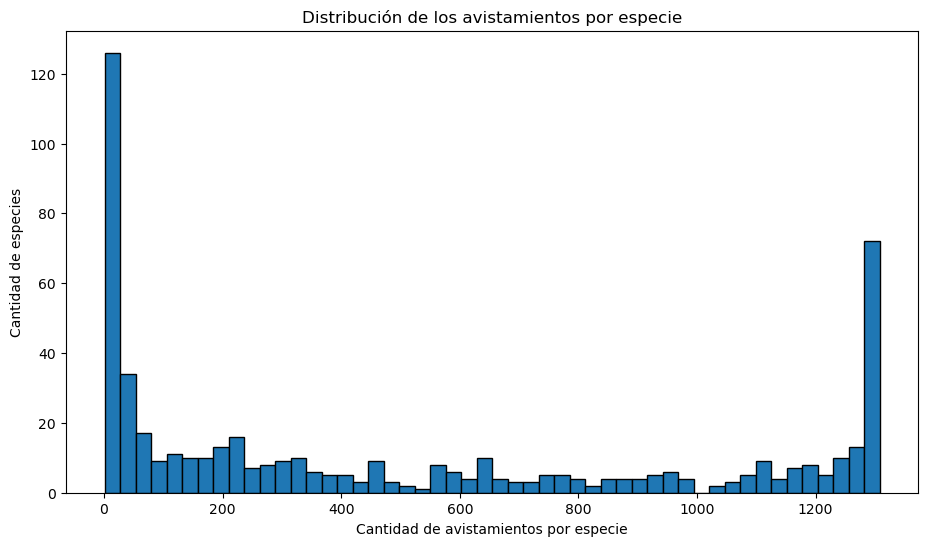

In [116]:
# Cargamos el dataset parquet
df = pd.read_parquet("observations_chile_2022_2025.parquet")

print('Columnas del DF: ', df.columns.tolist())

# Conteo de avistamientos por especie, de mayor a menor.
conteo_especies = df["comName"].value_counts() # value_counts() entrega la cantidad de ocurrencias de cada valor en una columna.

# Ahora, como el conteo tiene la cantidad total de avistamientos, y el enunciado pregunta por repeticiones,
# debemos restar 1 a cada avistamiento, así las especies que fueron avistadas una sola vez, quedan con 0 repeticiones:
repeticiones_especies = conteo_especies - 1

print('Conteo de avistamientos repetidos por especie:')
print(repeticiones_especies)

print('\n\nConteo de avistamientos por especie:')
print(conteo_especies)

# Luego, graficamos un histograma con la distribución de avistamientos por cada especie, para poder responder la pregunta final.

plt.figure(figsize=(11, 6))
plt.hist(conteo_especies, bins=50, edgecolor='black')
plt.title("Distribución de los avistamientos por especie")
plt.xlabel("Cantidad de avistamientos por especie")
plt.ylabel("Cantidad de especies")
plt.show()

Según la visualización de la 

### 3.2 Tranformación (1 punto)

**a) (0.5 pts)** Transforme la columna `obsDt` de string a un objeto de tipo `datetime` únicamente con año, mes y día (YYYY-MM-DD). Luego, agregue las siguientes nuevas columnas:
* `month` con únicamente el mes del avistamiento (puede dejar el mes como número entero de 1 a 12).
* `year-month` con el mes y año fecha en formato YYYY-MM

In [117]:
col_to_parse = df['obsDt'] # Col a utilizar.

# con to_datetime, seleccionamos la columna que queremos convertir a datetime,
# suponiendo que las entradas tienen valores con formato válido
df['obsDt'] = pd.to_datetime(col_to_parse, errors='coerce')

print("Primeras dos entradas de la columna obsDt parseada: \n", df['obsDt'].head(2), '\n')

# Generamos las cols de month y year-month
df['month'] = pd.to_datetime(df['obsDt']).dt.strftime('%m')
df['year-month'] = pd.to_datetime(df['obsDt']).dt.strftime('%Y-%m')

# Mostramos las columnas de interés, que son obsDt y las nuevas agregadas.
print("Dataset filtrado, con nuevas columnas month y year-month:")
print(df[['obsDt','month','year-month']].head())

Primeras dos entradas de la columna obsDt parseada: 
 0   2022-01-01 23:41:00
1   2022-01-01 22:18:00
Name: obsDt, dtype: datetime64[ns] 

Dataset filtrado, con nuevas columnas month y year-month:
                obsDt month year-month
0 2022-01-01 23:41:00    01    2022-01
1 2022-01-01 22:18:00    01    2022-01
2 2022-01-01 22:18:00    01    2022-01
3 2022-01-01 22:18:00    01    2022-01
4 2022-01-01 22:18:00    01    2022-01


**b) (0.5 pts)** Averigue cómo tranformar su DataFrame de Pandas en un GeoDataFrame de GeoPandas. Para esto, utilice las columnas `lat`y `lng` para generar los puntos de la nueva columna `geometry`. Para las visualizaciones siguientes utilizaremos el Coordinate Reference System (CRS) EPSG 4326 (también llamado [WGS 84](https://es.wikipedia.org/wiki/WGS84)). Asegúrese que sus coordenadas correspondan a este CRS al crear su GeoDataFrame.

In [118]:
from shapely.geometry import Point

# Primero que nada, usamos dropna para eliminar las filas que no tienen
# información geográfica, así evitamos errores posteriormentes, hacemos una
# copia del DF sin esas filas.
df_geo = df.dropna(subset=['lat','lng']).copy()

# Ahora viene la parte más importante, debemos crear una nueva columna
# geometry, y poner cada punto a partir de las columnas lat y lng, para cada
# entrada del DF.
df_geo['geometry'] = [Point(xy) for xy in zip(df_geo['lng'], df_geo['lat'])]

# Luego, usamos la columna geometry generada anteriormente, con la 
# proyección estándar:
gdf = gpd.GeoDataFrame(df_geo, geometry='geometry', crs='EPSG:4326')

print(gdf[['comName','lat','lng','geometry']].head())
print("\n CRS del DF:", gdf.crs)

             comName        lat        lng                     geometry
0    Queltehue común -40.585844 -73.113157  POINT (-73.11316 -40.58584)
1    Bandurria común -53.214573 -70.947665  POINT (-70.94766 -53.21457)
2          Tucúquere -53.214573 -70.947665  POINT (-70.94766 -53.21457)
3  Zorzal patagónico -53.214573 -70.947665  POINT (-70.94766 -53.21457)
4            Chincol -53.214573 -70.947665  POINT (-70.94766 -53.21457)

 CRS del DF: EPSG:4326


### 3.3 Exploración del dataset (1 punto)

**a) (0.3 pts)** Utilice `geopandas` para leer el archivo `Regional.shp` descargado de BCN. Asegúrese de que su CRS sea el mismo que utilizó en la sección anterior.

In [119]:
shp_path = os.path.join("Regiones", "Regional.shp") # path del shapefile!

# Leemos el shapefile y lo convertimos a la proyección de la sección anterior.
regiones = gpd.read_file(shp_path)
regiones = regiones.to_crs("EPSG:4326") # Convertimos la proyeción a EPSG:4326
print("\n CRS del DF:", regiones.crs)

print(f"Primeras filas del df regiones, con el método .head():")
print(regiones.head(2))


 CRS del DF: EPSG:4326
Primeras filas del df regiones, con el método .head():
   objectid  cir_sena  codregion       area_km    st_area_sh    st_length_  \
0      1084         1         15  16866.819844  1.886869e+10  7.505296e+05   
1      1085         2          1  42284.567484  4.830637e+10  1.213713e+06   

                         Region  \
0  Región de Arica y Parinacota   
1            Región de Tarapacá   

                                            geometry  
0  POLYGON ((-69.41531 -17.65521, -69.40802 -17.6...  
1  MULTIPOLYGON (((-70.16034 -20.2107, -70.16031 ...  


**b) (0.7 pts)** Grafique un mapa de Chile con todos los avistamientos de su dataset como puntos en el mapa. Comente: ¿Cómo se distribuyen estos avistamientos? ¿Hay lugares en Chile donde haya una menor densidad de datos? ¿Cuáles? 

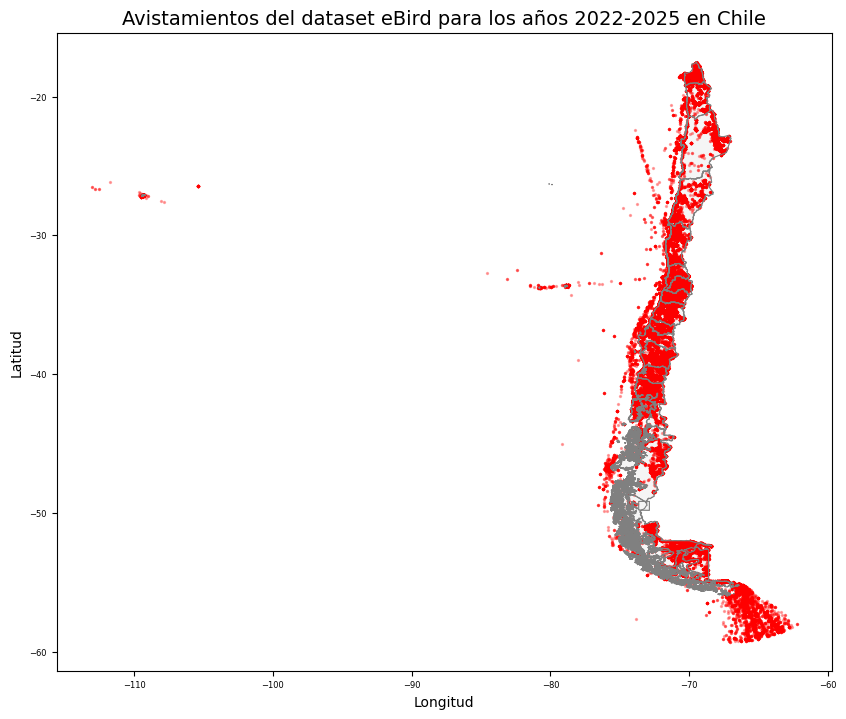

In [120]:
# Creamos el plot con la librería matplotlib
fig, ax = plt.subplots(figsize=(10, 14))

regiones.boundary.plot(ax=ax, color='gray', linewidth=0.8)
regiones.plot(ax=ax, color='#f5f5f5', edgecolor='gray', linewidth=0.3)

# Puntos de avistamientos
gdf.plot(ax=ax, markersize=2, color='red', alpha=0.3)


# El título puede ser engañoso, porque no es exactamente desde el primer día del 2022 al último del 2025.
ax.set_title("Avistamientos del dataset eBird para los años 2022-2025 en Chile", fontsize=14)
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
ax.set_aspect('equal') # Para que las escalas en los ejes x e y sean iguales. Mantener proporción.
ax.tick_params(labelsize=6)

plt.show()

Como se puede apreciar en el gráfico, los avistamientos indican una distribución de aves dentro del territorio nacional muy concentrada en regiones alrededor de la región metropolitana, pero menos en zonas extremas del norte y del sur, excepto al fondo del territorio, donde se pueden notar muchos avistamientos. También se ven avistamientos en zonas alejadas de tierra firme, como también en de la Isla de Pascua. Podemos notar que, sin contar con el extremo sur, hay grandes territorios de la zona sur del país que tienen menores avistamientos, como también en la tercera región desde arriba hacia abajo.

### 3.4 Visualización de migraciones (2.5 puntos)

**a) (0.2 pts)** Vamos a inspeccionar los avistamientos de las siguientes 2 especies en particular:

* Run-run [(*Hymenops perspicillatus*)](https://www.avesdechile.cl/171.htm)
* Dormilona tontita [(*Muscisaxicola maclovianus*)](https://www.avesdechile.cl/043.htm)

Primero, genere dos nuevos dataframes con los avistamientos de cada especie por separado.

In [121]:
runrun_name = "Run-run"
dormilona_name = "Dormilona tontita"

# Para generar nuevos df, simplemente filtramos el DF original, con la condición que los datos de la columna
# comName sean iguales al nombre de la especie que buscamos, y hacemos una copia, para no alterar el DF original.
df_runrun = df[df['comName'] == runrun_name].copy()
df_dormilona = df[df['comName'] == dormilona_name].copy()

print(f"Avistamientos de la especie {runrun_name}: {len(df_runrun)}")
print(f"Avistamientos de la especie {dormilona_name}: {len(df_dormilona)}")

print(df_runrun[['obsDt','comName']].head(2))
print(df_dormilona[['obsDt','comName']].head(2))

Avistamientos de la especie Run-run: 723
Avistamientos de la especie Dormilona tontita: 1155
                  obsDt  comName
49  2022-01-01 19:35:00  Run-run
204 2022-01-02 20:45:00  Run-run
                  obsDt            comName
389 2022-01-02 04:00:00  Dormilona tontita
513 2022-01-03 12:44:00  Dormilona tontita


**b) (0.8 pts)** Para cada una de estas especies, agrupe los datos según `year-month`. Luego, realice un gráfico que muestre la cantidad de avistamientos en el tiempo, empezando desde enero del 2022 hasta julio de 2025. Responda: ¿cómo varía cantidad de avistamientos para estas dos especies? ¿Cuáles son sus diferencias?

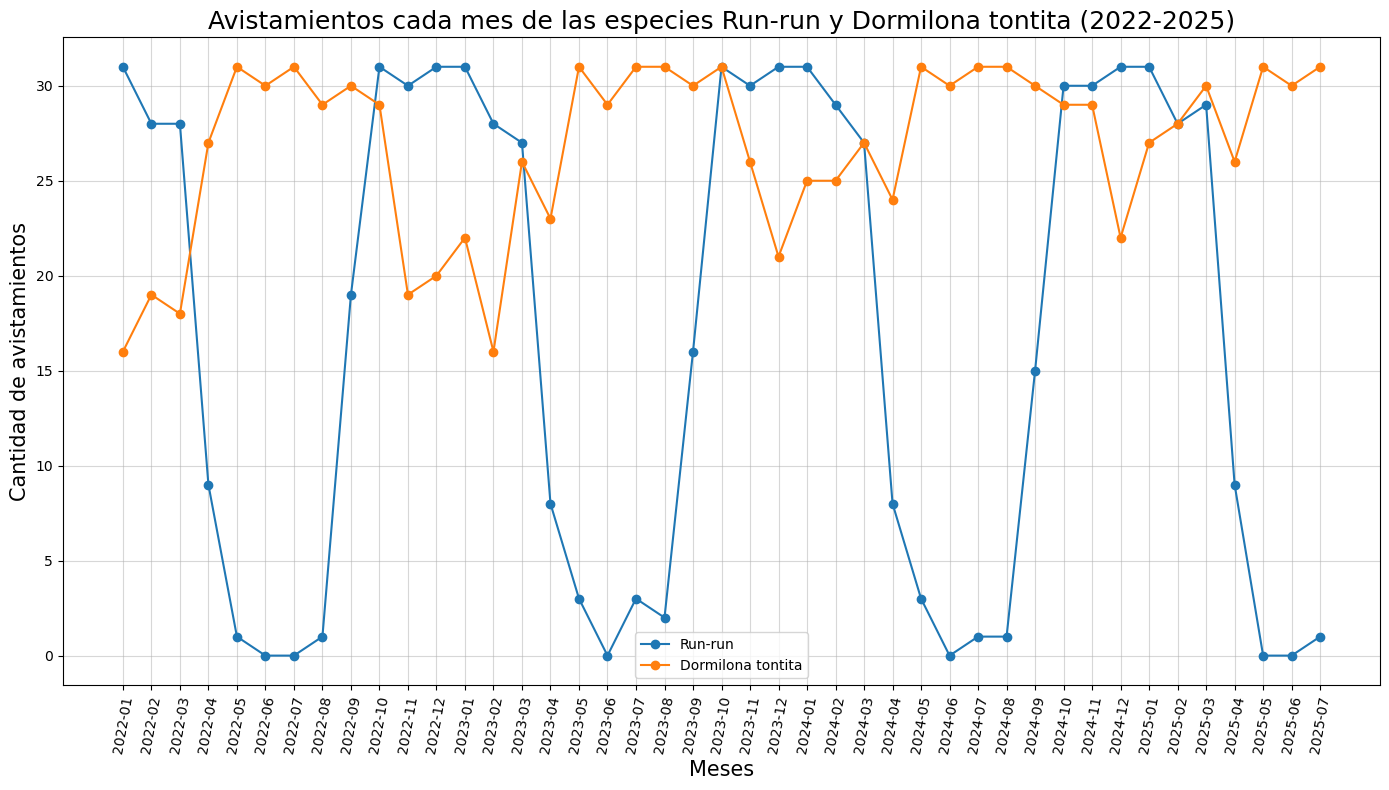

In [122]:
# Hacemos una lista en el periodo indicado, con una frecuencia mensual para la variación de los avistamientos.
months = pd.period_range('2022-01', '2025-07', freq='M').astype(str)

# Contamos los avistamientos por mes con .value_counts(), y luego reindexamos según la lista de meses creada anteriormente.
# Llenamos valores faltantes con 0, que en este caso son los meses en los que no hubo avistamientos.
runrun_avistamiento = df_runrun['year-month'].value_counts().reindex(months, fill_value=0)
dormilona_avistamiento = df_dormilona['year-month'].value_counts().reindex(months, fill_value=0)

plt.figure(figsize=(14,8)) # Hacemos el plot
# Ponemos los avistamientos de las dos aves en el mismo plot.
plt.plot(months, runrun_avistamiento.values, marker='o', label='Run-run')
plt.plot(months, dormilona_avistamiento.values, marker='o', label='Dormilona tontita')

plt.xticks(rotation=80) # Leve rotación para leer mejor los ticks.
plt.title(
    "Avistamientos cada mes de las especies Run-run y Dormilona tontita (2022-2025)", 
    fontsize=18
)
plt.xlabel("Meses", fontsize=15)
plt.ylabel("Cantidad de avistamientos", fontsize=15)
plt.legend() # Para poder diferenciar las dos especies en el plot.
plt.grid(alpha=0.5)
plt.tight_layout() # Para que no se corten las labels.
plt.show()

Como podemos ver en el gráfico, la especie Run-run tiene una variación de avistamientos muy grande entre ciertos periodos, normalmente se deja de avistar a mitad del año, y su avistamiento vuelve a elevarse entre los meses 8 y 9 del año, es un ave claramente estacional (seasonal).

La especie de ave Dormilona Tontita es similar en el sentido en el que se ve claramente un patrón de variación en los avistamientos, pero éstos incrementan en los meses en los que justamente los de la especie Run-run decrecen, se podría decir que existe una cierta relación inversa de avistamientos entre las aves, para ciertos periodos de tiempo. También hay que agregar dos cosas notables; primeramente, Dormilona Tontita tiene una distribución de avistamientos en el tiempo más errática, ya que el gráfico sube y baja entre meses, también podemos notar que su cantidad de avistamientos no varía tanto como la de la especie Run-run, y tampoco llega a tener una cantidad de avistamientos tan bajos, ya que vemos que el mínimo mensual es de aproximadamente 16, según las fechas analizadas.

**b) (1 pto)** Grafique en un mapa de Chile la ubicación de cada avistamiento para cada especie mencionada por separado. Utilice el color de cada punto como indicador del mes de avistamiento (columna `month`). Para esto, utilice un **colormap cíclico** para representar los meses del año. Puede utilizar el colormap disponible en la siguiente celda, o bien utilizar otro (siempre y cuando sea cíclico).

c:\Users\pluta\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
c:\Users\pluta\anaconda3\Lib\site-packages\geopandas\geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


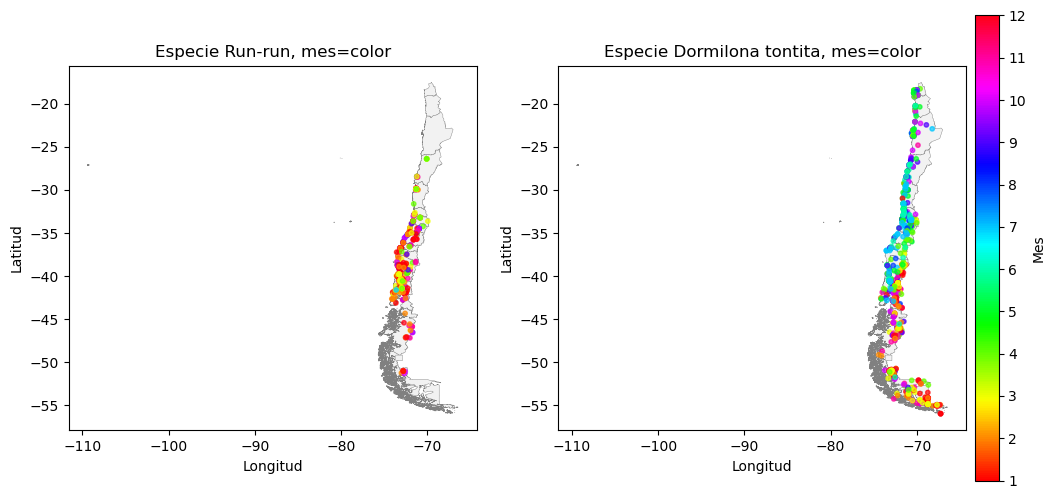

In [123]:
# Ya tenemos los DF de las dos especies filtradas que hemos copiado anteriormente.
# Hacemos lo mismo acá, creamos nuevos GDF a partir de los DF filtrados para las especies de interés:
gdf_runrun = gdf[gdf['comName'] == "Run-run"]
gdf_dormilona = gdf[gdf['comName'] == "Dormilona tontita"]

# Resolviendo error
gdf_runrun['month'] = gdf_runrun['month'].fillna(0).astype(int)
gdf_dormilona['month'] = gdf_dormilona['month'].fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 16)) # Creamos el plot, 

# Es importante destacar que, aquí al hacer el scatter, usaremos la columna de las geometrías del GDF.

# Plot de la especie Run-run
regiones.plot(ax=axes[0], color='#f2f2f2', edgecolor='gray', linewidth=0.3)
axes[0].scatter(
    gdf_runrun.geometry.x,
    gdf_runrun.geometry.y,
    c=gdf_runrun['month'], # c es la variable del color de cada punto.
    cmap='hsv', # COLORMAP CICLO HUE SIMPLE.
    vmin=1, vmax=12, # colores discretos para los 12 meses.
    s=10, alpha=0.7
)
axes[0].set_title("Especie Run-run, mes=color")
axes[0].set_xlabel("Longitud")
axes[0].set_ylabel("Latitud")
axes[0].set_aspect('equal') # Para que las escalas en los ejes x e y sean iguales. Mantener proporción.

# Plot de la especieDormilona
regiones.plot(ax=axes[1], color='#f2f2f2', edgecolor='gray', linewidth=0.3)
axes[1].scatter(
    gdf_dormilona.geometry.x,
    gdf_dormilona.geometry.y,
    c=gdf_dormilona['month'], # c es la variable del color de cada punto.
    cmap='hsv', # COLORMAP CICLO HUE SIMPLE.
    vmin=1, vmax=12, # colores discretos para los 12 meses.
    s=10, alpha=0.7
)
axes[1].set_title("Especie Dormilona tontita, mes=color")
axes[1].set_xlabel("Longitud")
axes[1].set_ylabel("Latitud")
axes[1].set_aspect('equal') # Para que las escalas en los ejes x e y sean iguales. Mantener proporción.

# fig.suptitle("Distribución de especies, cada mes es un color diferente.", fontsize=8)
sm = plt.cm.ScalarMappable(cmap='hsv', norm=plt.Normalize(vmin=1, vmax=12))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.01)
cbar.set_ticks(range(1,13))
cbar.set_label("Mes")

plt.show()

**c) (0.5 pts)** Describa las migraciones de estas dos especies. ¿Cómo se diferencian?

Respuesta

Como vemos, la especie Run-run se mantiene cerca del centro del país, con migraciones hacia el sur y el norte, entre las latitudes -45 y -55 grados, especialmente durante el verano (que es el color rojo y naranja), mientras que durante el invierno, los avistamientos están más concentrados en el centro, también en zonas costeras.

En cuanto a Dormilona Tontita, se ve una distribución migratoria a lo largo de casi todo el país, tiene un claro patrón de mantenerse en las zonas costeras durante los meses de invierno (celeste y azul), mientras que en los meses de color verde, que serían 4 al 6, se le ve en zonas de mayor altitud, cercanas a la cordillera, todo esto hablando de la región metropolitana y regiones cercanas a ésta. Mientras que en periodos de invierno, su migración se concentra más intensamenta en el extremo austral y en zonas del sur de Chile, donde se pueden ver más colores rojos.